# Time Comparison: `cloelib` vs `pyccl`

This notebook benchmarks the computation of angular power spectra $C_\ell$ (GG, GE, EE) using two codes:
- **cloelib** (`HMemuNonLinearPerturbations` + `AngularTwoPoint`)
- **pyccl** (`halofit` + `ccl.angular_cl`)

We use the Euclid SPV3 photometric redshift distributions from `nzTabSPV3.fits`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import timeit
from scipy import integrate

import euclidlib as el

# cloelib
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint

# pyccl
import pyccl as ccl

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)
plt.rc('lines', linewidth=2)
plt.rc('legend', fontsize=12)

/Users/guadalupecanasherrera/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


## Load and prepare $n(z)$ from `nzTabSPV3.fits`

Number of bins: 13
Redshift range: 0.000 – 6.000,  n_z = 3001


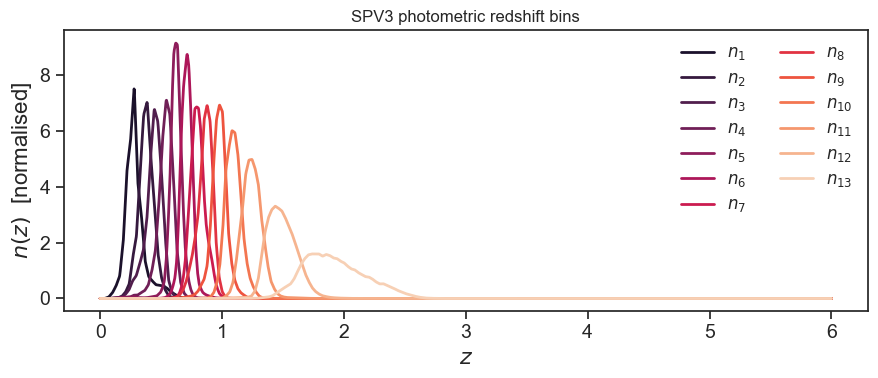

In [2]:
NZ_FILE = "nzTabSPV3.fits" #

# euclidlib reads the FITS file into z array + dict of per-bin n(z) arrays
z_nz, nz_spv3 = el.phz.redshift_distributions(NZ_FILE)

n_bins = len(nz_spv3)
print(f"Number of bins: {n_bins}")
print(f"Redshift range: {z_nz.min():.3f} – {z_nz.max():.3f},  n_z = {len(z_nz)}")

# Normalise n(z) so that ∫n(z)dz = 1
def normalize_dndz(nz_dict, z):
    return {k: v / integrate.trapezoid(v, z) for k, v in nz_dict.items()}

dndz_norm = normalize_dndz(nz_spv3, z_nz)

# Resample onto a uniform z grid used by cloelib
zs = np.linspace(1e-4, 3.0, 100)

def resample_dndz(nz_dict, z_src, z_tgt):
    stacked = np.vstack(list(nz_dict.values()))
    out = np.zeros((len(nz_dict), len(z_tgt)))
    for i in range(len(nz_dict)):
        out[i] = np.interp(z_tgt, z_src, stacked[i])
    return out

my_dndz_norm = resample_dndz(dndz_norm, z_nz, zs)

# Quick plot
colors = sns.color_palette("rocket", n_bins)
plt.figure(figsize=(9, 4))
for i, (key, col) in enumerate(zip(dndz_norm, colors)):
    plt.plot(z_nz, dndz_norm[key], color=col, label=f'$n_{{{i+1}}}$')
plt.xlabel(r'$z$')
plt.ylabel(r'$n(z)$  [normalised]')
plt.title('SPV3 photometric redshift bins')
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

## `cloelib` — cosmology, tracers and $C_\ell$ function

In [3]:
background = CAMBBackground(
    H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
    w0=-1.0, wa=0.0, Omega_k0=0.0,
    ns=0.96, As=2e-9, mnu=0.06,
    gamma_MG=0.545, N_mnu=1,
)
linear_pert  = HMemuLinearPerturbations(background, zs)
nonlin_pert  = HMemuNonLinearPerturbations(background, linear_pert, zs, log10TAGN=7.8)

ells = np.arange(2, 3000)

# Nuisance params — zero shifts, unit width, flat bias
nuisance_pos = {
    'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0,
    'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
    **{f'magnification_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
    **{f'dz_pos_{i}': 0.0 for i in range(1, n_bins + 1)},
    **{f'width_pos_{i}': 1.0 for i in range(1, n_bins + 1)},
}
nuisance_she = {
    'AIA': 1.72, 'CIA': 0.0134, 'EtaIA': -0.41,
    **{f'multiplicative_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
    **{f'dz_shear_{i}': 0.0 for i in range(1, n_bins + 1)},
    **{f'width_shear_{i}': 1.0 for i in range(1, n_bins + 1)},
}

tracer_pos_cl = PositionsTracer(
    perturbations=nonlin_pert, dndz=my_dndz_norm,
    z=zs, galaxy_bias_model='poly', nuisance_params=nuisance_pos,
)
tracer_she_cl = ShearTracer(
    perturbations=nonlin_pert, dndz=my_dndz_norm,
    z=zs, nuisance_params=nuisance_she,
)

tp_gg = AngularTwoPoint(tracer_pos_cl, tracer_pos_cl)
tp_ge = AngularTwoPoint(tracer_pos_cl, tracer_she_cl)
tp_ee = AngularTwoPoint(tracer_she_cl, tracer_she_cl)

def compute_cls_cloelib():
    cells = {}
    cells.update(tp_gg.get_Cl(ells, 0, nonlin_pert.k))
    cells.update(tp_ge.get_Cl(ells, 0, nonlin_pert.k))
    cells.update(tp_ee.get_Cl(ells, 0, nonlin_pert.k))
    return cells

print("cloelib setup done")

cloelib setup done


## `pyccl` — cosmology, tracers and $C_\ell$ function

In [4]:
cosmo_ccl = ccl.Cosmology(
    h=0.70, Omega_c=0.25, Omega_b=0.05,
    w0=-1.0, wa=0.0, n_s=0.96, A_s=2e-9,
    m_nu=0.06, Omega_k=0.0,
    matter_power_spectrum='halofit',
)

# Pre-compute the power spectrum once
cosmo_ccl.compute_nonlin_power()

AIA, CIA, EtaIA = 1.72, 0.0134, -0.41
ia_bias = AIA * CIA * (1.0 + z_nz) ** EtaIA

tracers_pos_ccl = [
    ccl.NumberCountsTracer(
        cosmo_ccl,
        dndz=(z_nz, dndz_norm[k]),
        bias=(z_nz, np.ones_like(z_nz)),
        has_rsd=False,
    )
    for k in dndz_norm
]
tracers_she_ccl = [
    ccl.WeakLensingTracer(
        cosmo_ccl,
        dndz=(z_nz, dndz_norm[k]),
        ia_bias=(z_nz, ia_bias),
    )
    for k in dndz_norm
]

ells_ccl = np.arange(2, 3000)

def compute_cls_ccl():
    cls = {}
    # Use 'fkem' integration method (faster than default 'limber' for many ells)
    for i in range(n_bins):
        for j in range(i, n_bins):
            cls['GG', i, j] = ccl.angular_cl(cosmo_ccl, tracers_pos_ccl[i], tracers_pos_ccl[j], ells_ccl, limber_integration_method='spline')
        for j in range(n_bins):
            cls['GE', i, j] = ccl.angular_cl(cosmo_ccl, tracers_pos_ccl[i], tracers_she_ccl[j], ells_ccl, limber_integration_method='spline')
        for j in range(i, n_bins):
            cls['EE', i, j] = ccl.angular_cl(cosmo_ccl, tracers_she_ccl[i], tracers_she_ccl[j], ells_ccl, limber_integration_method='spline')
    return cls

print("pyccl setup done")

pyccl setup done


## Timing sweep over $n_z$ and $n_\ell$

We sweep over:
- **`n_z`** — number of points in the cloelib redshift integration grid  
- **`n_ell`** — number of $\ell$ values passed to both codes  

For each combination we record the median wall-clock time over `N_REPEAT` runs.  
The pyccl tracers use the native `z_nz` grid from the FITS file, so `n_z` only affects cloelib.

In [5]:
N_REPEAT = 3  # timing runs per configuration

# Grid of parameters to sweep
nz_values   = [100, 1000, 4000]            # cloelib z-grid sizes
nell_values = [20]  # ell array lengths

# Results storage:  results[code][n_z][n_ell] = median time in seconds
results_cl  = {nz: {} for nz in nz_values}   # cloelib
results_ccl = {nz: {} for nz in nz_values}   # pyccl (same n_z key for alignment)

for nz in nz_values:
    print(f"\n── n_z = {nz} ─────────────────────")
    
    # ── cloelib: rebuild perturbations + tracers for this z-grid ──
    zs_sweep = np.linspace(1e-4, 3.0, nz)
    my_dndz_nz = resample_dndz(dndz_norm, z_nz, zs_sweep)

    bg     = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
                            w0=-1.0, wa=0.0, Omega_k0=0.0, ns=0.96, As=2e-9,
                            mnu=0.06, gamma_MG=0.545, N_mnu=1)
    lin    = HMemuLinearPerturbations(bg, zs_sweep)
    nonlin = HMemuNonLinearPerturbations(bg, lin, zs_sweep, log10TAGN=7.8)

    nuis_p = {'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0,
              'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
              **{f'magnification_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
              **{f'dz_pos_{i}': 0.0 for i in range(1, n_bins + 1)},
              **{f'width_pos_{i}': 1.0 for i in range(1, n_bins + 1)}}
    nuis_s = {'AIA': 1.72, 'CIA': 0.0134, 'EtaIA': -0.41,
              **{f'multiplicative_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
              **{f'dz_shear_{i}': 0.0 for i in range(1, n_bins + 1)},
              **{f'width_shear_{i}': 1.0 for i in range(1, n_bins + 1)}}

    tr_pos = PositionsTracer(perturbations=nonlin, dndz=my_dndz_nz, z=zs_sweep,
                             galaxy_bias_model='poly', nuisance_params=nuis_p)
    tr_she = ShearTracer(perturbations=nonlin, dndz=my_dndz_nz, z=zs_sweep,
                         nuisance_params=nuis_s)
    tp_gg_ = AngularTwoPoint(tr_pos, tr_pos)
    tp_ge_ = AngularTwoPoint(tr_pos, tr_she)
    tp_ee_ = AngularTwoPoint(tr_she, tr_she)

    for nell in nell_values:
        ells_sweep = np.unique(np.geomspace(2, 2999, nell).astype(int))

        # cloelib timing
        def _cl():
            c = {}
            c.update(tp_gg_.get_Cl(ells_sweep, 0, nonlin.k))
            c.update(tp_ge_.get_Cl(ells_sweep, 0, nonlin.k))
            c.update(tp_ee_.get_Cl(ells_sweep, 0, nonlin.k))
            return c

        t_cl = timeit.repeat(_cl, repeat=N_REPEAT, number=1)
        results_cl[nz][nell] = np.median(t_cl)

        # pyccl timing (tracers fixed; only ell array varies)
        def _ccl():
            cls = {}
            for i in range(n_bins):
                for j in range(i, n_bins):
                    cls['GG', i, j] = ccl.angular_cl(cosmo_ccl, tracers_pos_ccl[i],
                                                      tracers_pos_ccl[j], ells_sweep,
                                                      limber_integration_method='qag_quad')
                for j in range(n_bins):
                    cls['GE', i, j] = ccl.angular_cl(cosmo_ccl, tracers_pos_ccl[i],
                                                      tracers_she_ccl[j], ells_sweep,
                                                      limber_integration_method='qag_quad')
                for j in range(i, n_bins):
                    cls['EE', i, j] = ccl.angular_cl(cosmo_ccl, tracers_she_ccl[i],
                                                      tracers_she_ccl[j], ells_sweep,
                                                      limber_integration_method='spline')
            return cls

        t_ccl = timeit.repeat(_ccl, repeat=N_REPEAT, number=1)
        results_ccl[nz][nell] = np.median(t_ccl)

        print(f"  n_ell={nell:5d} | cloelib {results_cl[nz][nell]:.2f}s  "
              f"pyccl {results_ccl[nz][nell]:.2f}s  "
              f"ratio {results_cl[nz][nell]/results_ccl[nz][nell]:.2f}x")

print("\nSweep complete.")


── n_z = 100 ─────────────────────
  n_ell=   20 | cloelib 0.13s  pyccl 0.44s  ratio 0.30x

── n_z = 1000 ─────────────────────
  n_ell=   20 | cloelib 0.18s  pyccl 0.40s  ratio 0.45x

── n_z = 4000 ─────────────────────
  n_ell=   20 | cloelib 0.92s  pyccl 0.45s  ratio 2.05x

Sweep complete.


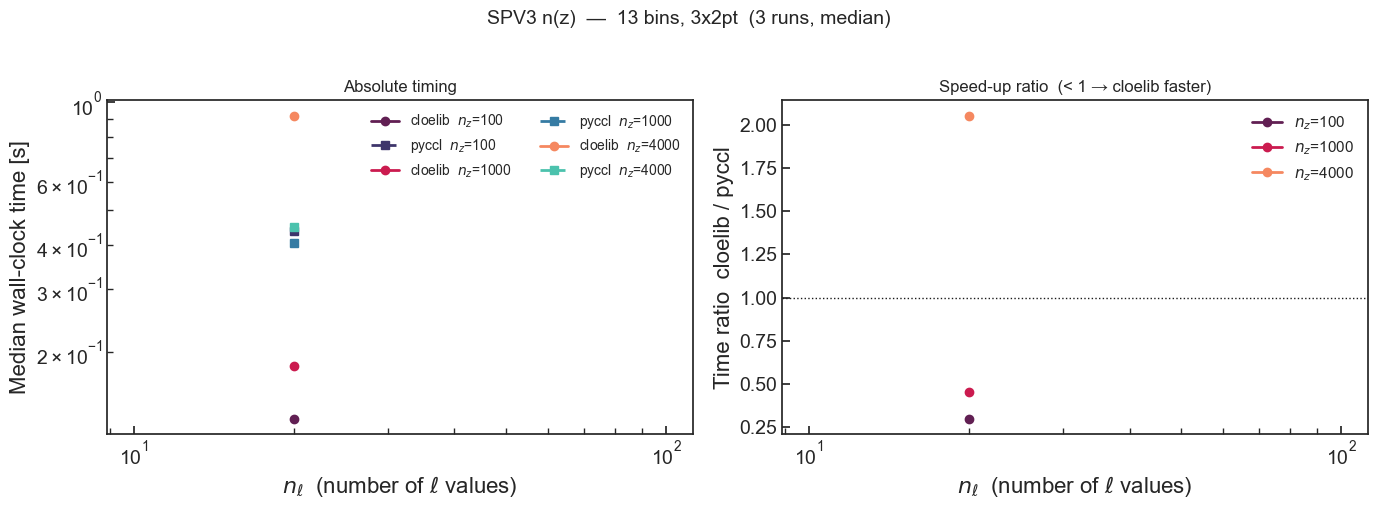

In [6]:
pal_cl  = sns.color_palette("rocket",  len(nz_values))
pal_ccl = sns.color_palette("mako",    len(nz_values))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax_t, ax_r = axes
nell_arr = np.array(nell_values)

for idx, nz in enumerate(nz_values):
    t_cl_arr  = np.array([results_cl[nz][n]  for n in nell_values])
    t_ccl_arr = np.array([results_ccl[nz][n] for n in nell_values])
    ratio_arr = t_cl_arr / t_ccl_arr

    ax_t.plot(nell_arr, t_cl_arr,  color=pal_cl[idx],  lw=2,
              marker='o', label=f'cloelib  $n_z$={nz}')
    ax_t.plot(nell_arr, t_ccl_arr, color=pal_ccl[idx], lw=2,
              marker='s', ls='--', label=f'pyccl  $n_z$={nz}')

    ax_r.plot(nell_arr, ratio_arr, color=pal_cl[idx], lw=2,
              marker='o', label=f'$n_z$={nz}')

ax_t.set_xlabel(r'$n_\ell$  (number of $\ell$ values)')
ax_t.set_ylabel('Median wall-clock time [s]')
ax_t.set_title('Absolute timing')
ax_t.set_xscale('log')
ax_t.set_yscale('log')
ax_t.legend(fontsize=10, frameon=False, ncol=2)
ax_t.tick_params(axis='both', which='both', direction='in')

ax_r.axhline(1.0, color='k', lw=1, ls=':')
ax_r.set_xlabel(r'$n_\ell$  (number of $\ell$ values)')
ax_r.set_ylabel('Time ratio  cloelib / pyccl')
ax_r.set_title('Speed-up ratio  (< 1 → cloelib faster)')
ax_r.set_xscale('log')
ax_r.legend(fontsize=11, frameon=False)
ax_r.tick_params(axis='both', which='both', direction='in')

plt.suptitle(f'SPV3 n(z)  —  {n_bins} bins, 3x2pt  ({N_REPEAT} runs, median)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('time_comparison_SPV3_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Timing as a function of number of redshift bins

Fixed settings: **`n_z = 200`**, **`n_ell = 100`** (log-spaced).  
We progressively use the first `n_b` bins from the full 13-bin SPV3 n(z), and time the complete GG + GE + EE computation for both codes.  
The number of spectra scales as $n_b(2n_b+1)$, so we expect roughly quadratic scaling.

In [7]:
NZ_BINS   = 150    # fixed z-grid size for cloelib
NELL_BINS = 20    # fixed number of ell values

# Bin counts to sweep (up to the total available)
max_bins = len(dndz_norm)
nbin_values = [b for b in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] if b <= max_bins]

print(f"Total bins in file: {max_bins}")
print(f"Sweeping n_bins = {nbin_values}\n")

ells_bins  = np.unique(np.geomspace(2, 2999, NELL_BINS).astype(int))
zs_bins    = np.linspace(1e-4, 3.0, NZ_BINS)

# Pre-build cloelib perturbations once (z-grid fixed)
bg_b   = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
                        w0=-1.0, wa=0.0, Omega_k0=0.0, ns=0.96, As=2e-9,
                        mnu=0.06, gamma_MG=0.545, N_mnu=1)
lin_b  = HMemuLinearPerturbations(bg_b, zs_bins)
nlin_b = HMemuNonLinearPerturbations(bg_b, lin_b, zs_bins, log10TAGN=7.8)

# Results storage
results_bins_cl  = {}
results_bins_ccl = {}

all_keys = list(dndz_norm.keys())

for nb in nbin_values:
    keys_nb  = all_keys[:nb]
    dndz_nb  = {k: dndz_norm[k] for k in keys_nb}
    dndz_nb_resampled = resample_dndz(dndz_nb, z_nz, zs_bins)

    # ── cloelib ──
    nuis_p_b = {'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0,
                'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
                **{f'magnification_bias_{i}': 0.0 for i in range(1, nb + 1)},
                **{f'dz_pos_{i}': 0.0 for i in range(1, nb + 1)},
                **{f'width_pos_{i}': 1.0 for i in range(1, nb + 1)}}
    nuis_s_b = {'AIA': 1.72, 'CIA': 0.0134, 'EtaIA': -0.41,
                **{f'multiplicative_bias_{i}': 0.0 for i in range(1, nb + 1)},
                **{f'dz_shear_{i}': 0.0 for i in range(1, nb + 1)},
                **{f'width_shear_{i}': 1.0 for i in range(1, nb + 1)}}

    tr_p_b = PositionsTracer(perturbations=nlin_b, dndz=dndz_nb_resampled,
                             z=zs_bins, galaxy_bias_model='poly', nuisance_params=nuis_p_b)
    tr_s_b = ShearTracer(perturbations=nlin_b, dndz=dndz_nb_resampled,
                         z=zs_bins, nuisance_params=nuis_s_b)
    gg_b = AngularTwoPoint(tr_p_b, tr_p_b)
    ge_b = AngularTwoPoint(tr_p_b, tr_s_b)
    ee_b = AngularTwoPoint(tr_s_b, tr_s_b)

    def _cl_bins():
        c = {}
        c.update(gg_b.get_Cl(ells_bins, 0, nlin_b.k))
        c.update(ge_b.get_Cl(ells_bins, 0, nlin_b.k))
        c.update(ee_b.get_Cl(ells_bins, 0, nlin_b.k))
        return c

    results_bins_cl[nb] = np.median(timeit.repeat(_cl_bins, repeat=N_REPEAT, number=1))

    # ── pyccl ──
    ia_bias_b = AIA * CIA * (1.0 + z_nz) ** EtaIA
    tr_pos_ccl_b = [
        ccl.NumberCountsTracer(cosmo_ccl, dndz=(z_nz, dndz_nb[k]),
                               bias=(z_nz, np.ones_like(z_nz)), has_rsd=False)
        for k in keys_nb
    ]
    tr_she_ccl_b = [
        ccl.WeakLensingTracer(cosmo_ccl, dndz=(z_nz, dndz_nb[k]),
                              ia_bias=(z_nz, ia_bias_b))
        for k in keys_nb
    ]

    def _ccl_bins():
        cls = {}
        for i in range(nb):
            for j in range(i, nb):
                cls['GG', i, j] = ccl.angular_cl(cosmo_ccl, tr_pos_ccl_b[i],
                                                  tr_pos_ccl_b[j], ells_bins,
                                                  limber_integration_method='qag_quad')
            for j in range(nb):
                cls['GE', i, j] = ccl.angular_cl(cosmo_ccl, tr_pos_ccl_b[i],
                                                  tr_she_ccl_b[j], ells_bins,
                                                  limber_integration_method='qag_quad')
            for j in range(i, nb):
                cls['EE', i, j] = ccl.angular_cl(cosmo_ccl, tr_she_ccl_b[i],
                                                  tr_she_ccl_b[j], ells_bins,
                                                  limber_integration_method='qag_quad')
        return cls

    results_bins_ccl[nb] = np.median(timeit.repeat(_ccl_bins, repeat=N_REPEAT, number=1))

    n_spectra = nb * (2 * nb + 1)
    print(f"  n_bins={nb:2d}  ({n_spectra:3d} spectra) | "
          f"cloelib {results_bins_cl[nb]:.2f}s  "
          f"pyccl {results_bins_ccl[nb]:.2f}s  "
          f"ratio {results_bins_cl[nb]/results_bins_ccl[nb]:.2f}x")

print("\nBin sweep complete.")

Total bins in file: 13
Sweeping n_bins = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

  n_bins= 1  (  3 spectra) | cloelib 0.02s  pyccl 0.00s  ratio 8.66x
  n_bins= 2  ( 10 spectra) | cloelib 0.02s  pyccl 0.01s  ratio 2.11x
  n_bins= 3  ( 21 spectra) | cloelib 0.03s  pyccl 0.02s  ratio 1.37x
  n_bins= 4  ( 36 spectra) | cloelib 0.03s  pyccl 0.04s  ratio 0.73x
  n_bins= 5  ( 55 spectra) | cloelib 0.04s  pyccl 0.06s  ratio 0.71x
  n_bins= 6  ( 78 spectra) | cloelib 0.04s  pyccl 0.09s  ratio 0.46x
  n_bins= 7  (105 spectra) | cloelib 0.05s  pyccl 0.16s  ratio 0.32x
  n_bins= 8  (136 spectra) | cloelib 0.07s  pyccl 0.18s  ratio 0.38x
  n_bins= 9  (171 spectra) | cloelib 0.08s  pyccl 0.23s  ratio 0.35x
  n_bins=10  (210 spectra) | cloelib 0.08s  pyccl 0.27s  ratio 0.31x
  n_bins=11  (253 spectra) | cloelib 0.11s  pyccl 0.31s  ratio 0.35x
  n_bins=12  (300 spectra) | cloelib 0.11s  pyccl 0.38s  ratio 0.30x
  n_bins=13  (351 spectra) | cloelib 0.13s  pyccl 0.43s  ratio 0.30x

Bin sweep comple

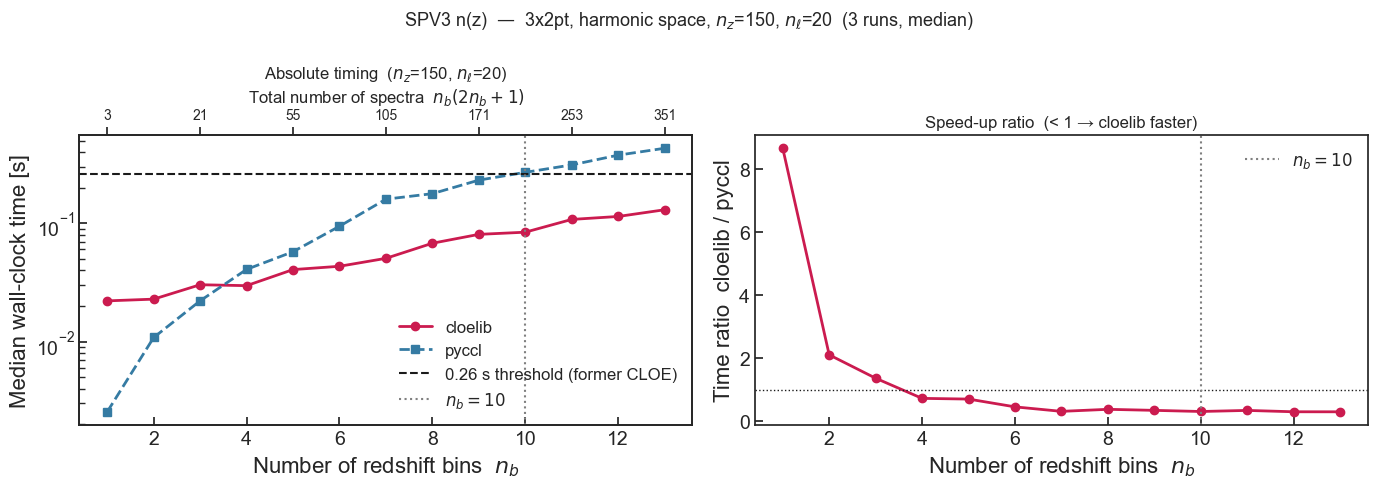

In [8]:
nbin_arr   = np.array(nbin_values)
t_cl_bins  = np.array([results_bins_cl[nb]  for nb in nbin_values])
t_ccl_bins = np.array([results_bins_ccl[nb] for nb in nbin_values])
ratio_bins = t_cl_bins / t_ccl_bins
n_spectra_arr = nbin_arr * (2 * nbin_arr + 1)

quad_ref = n_spectra_arr**2 / n_spectra_arr[0]**2 * t_cl_bins[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_t, ax_r = axes

col_cl  = sns.color_palette("rocket", 3)[1]
col_ccl = sns.color_palette("mako",   3)[1]

ax_t.plot(nbin_arr, t_cl_bins,  color=col_cl,  lw=2, marker='o', label='cloelib')
ax_t.plot(nbin_arr, t_ccl_bins, color=col_ccl, lw=2, marker='s', ls='--', label='pyccl')
ax_t.axhline(0.26, color='k', lw=1.5, ls='--', label='0.26 s threshold (former CLOE)')
ax_t.axvline(10, color='grey', lw=1.5, ls=':', label='$n_b=10$')
ax_t.set_xlabel('Number of redshift bins  $n_b$')
ax_t.set_ylabel('Median wall-clock time [s]')
ax_t.set_title(f'Absolute timing  ($n_z$={NZ_BINS}, $n_\\ell$={NELL_BINS})')
ax_t.set_yscale('log')
ax_t.legend(frameon=False)
ax_t.tick_params(axis='both', which='both', direction='in')

ax_top = ax_t.twiny()
ax_top.set_xlim(ax_t.get_xlim())
ax_top.set_xticks(nbin_arr[::2])
ax_top.set_xticklabels([str(n_spectra_arr[i]) for i in range(0, len(nbin_arr), 2)], fontsize=10)
ax_top.set_xlabel('Total number of spectra  $n_b(2n_b+1)$', fontsize=12)

ax_r.plot(nbin_arr, ratio_bins, color=col_cl, lw=2, marker='o')
ax_r.axhline(1.0, color='k', lw=1, ls=':')
ax_r.axvline(10, color='grey', lw=1.5, ls=':', label='$n_b=10$')
ax_r.set_xlabel('Number of redshift bins  $n_b$')
ax_r.set_ylabel('Time ratio  cloelib / pyccl')
ax_r.set_title('Speed-up ratio  (< 1 → cloelib faster)')
ax_r.tick_params(axis='both', which='both', direction='in')
ax_r.legend(frameon=False)

plt.suptitle(f'SPV3 n(z)  —  3x2pt, harmonic space, $n_z$={NZ_BINS}, $n_\\ell$={NELL_BINS}  ({N_REPEAT} runs, median)',
             fontsize=13)
plt.tight_layout()
plt.savefig('time_comparison_SPV3_bins.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
import os
import threading
import time

print(f"OMP_NUM_THREADS = {os.environ.get('OMP_NUM_THREADS', 'not set')}")
print(f"MKL_NUM_THREADS = {os.environ.get('MKL_NUM_THREADS', 'not set')}")
print(f"OPENBLAS_NUM_THREADS = {os.environ.get('OPENBLAS_NUM_THREADS', 'not set')}")

active_threads = []

def monitor_threads(duration=5, interval=0.1):
    max_threads = 0
    t_end = time.time() + duration
    while time.time() < t_end:
        n = threading.active_count()
        if n > max_threads:
            max_threads = n
        time.sleep(interval)
    return max_threads

# Run cloelib computation while monitoring thread count
monitor_results = []

def run_monitor():
    monitor_results.append(monitor_threads(duration=10, interval=0.05))

monitor_thread = threading.Thread(target=run_monitor)
monitor_thread.start()

# Run a cloelib computation
start = time.time()
_ = tp_gg.get_Cl(ells, 0, nonlin_pert.k)
elapsed = time.time() - start

monitor_thread.join()

print(f"\ncloelib get_Cl took {elapsed:.2f}s")
print(f"Max active Python threads observed during run: {monitor_results[0]}")
print(f"(baseline idle threads: {threading.active_count()})")
print("\nNote: Python thread count only detects Python-level threads.")
print("Use 'htop' or 'ps -eLf' during execution to detect native/OMP threads.")

OMP_NUM_THREADS = not set
MKL_NUM_THREADS = not set
OPENBLAS_NUM_THREADS = not set

cloelib get_Cl took 0.97s
Max active Python threads observed during run: 10
(baseline idle threads: 9)

Note: Python thread count only detects Python-level threads.
Use 'htop' or 'ps -eLf' during execution to detect native/OMP threads.


In [10]:
import os
import subprocess
import time
import threading

# Check OpenMP-related environment variables
print("=== Environment Variables ===")
for var in ['OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS']:
    print(f"{var} = {os.environ.get(var, 'not set')}")

# Try to detect number of threads used by pyccl via /proc (Linux only)
def count_threads_pid(pid):
    try:
        with open(f'/proc/{pid}/status') as f:
            for line in f:
                if line.startswith('Threads:'):
                    return int(line.split()[1])
    except Exception:
        return None

pid = os.getpid()
baseline_threads = count_threads_pid(pid)
print(f"\n=== Thread count (via /proc) ===")
print(f"Baseline threads before pyccl call: {baseline_threads}")

# Monitor threads in background while running pyccl
max_threads_observed = [baseline_threads or 0]

def monitor():
    t_end = time.time() + 30
    while time.time() < t_end:
        n = count_threads_pid(pid)
        if n and n > max_threads_observed[0]:
            max_threads_observed[0] = n
        time.sleep(0.01)

mon = threading.Thread(target=monitor, daemon=True)
mon.start()

# Run a moderately expensive pyccl computation
print("\nRunning pyccl angular_cl to probe thread usage...")
t0 = time.time()
_ = ccl.angular_cl(cosmo_ccl, tracers_pos_ccl[0], tracers_she_ccl[-1],
                   np.arange(2, 3000), limber_integration_method='qag_quad')
elapsed = time.time() - t0

mon.join(timeout=1)

print(f"pyccl angular_cl took {elapsed:.3f}s")
print(f"Max threads observed during run: {max_threads_observed[0]}  (baseline: {baseline_threads})")

# Also try via `ps` for native thread count
try:
    result = subprocess.run(['ps', '-o', 'nlwp=', '-p', str(pid)],
                            capture_output=True, text=True)
    print(f"Native threads (ps nlwp): {result.stdout.strip()}")
except Exception as e:
    print(f"ps query failed: {e}")

# Check if pyccl was compiled with OMP
try:
    import pyccl._core as _cc
    print(f"\npyccl version: {ccl.__version__}")
except Exception:
    pass

print("\nNote: if max_threads > baseline, pyccl is spawning native OMP/pthreads.")

=== Environment Variables ===
OMP_NUM_THREADS = not set
MKL_NUM_THREADS = not set
OPENBLAS_NUM_THREADS = not set
NUMEXPR_NUM_THREADS = not set

=== Thread count (via /proc) ===
Baseline threads before pyccl call: None

Running pyccl angular_cl to probe thread usage...
pyccl angular_cl took 0.168s
Max threads observed during run: 0  (baseline: None)
Native threads (ps nlwp): %cpu %mem acflag acflg args blocked comm command cpu cputime etime f flags gid
group inblk inblock jobc ktrace ktracep lim login logname lstart majflt minflt
msgrcv msgsnd ni nice nivcsw nsignals nsigs nswap nvcsw nwchan oublk oublock
p_ru paddr pagein pcpu pending pgid pid pmem ppid pri prsna pstime putime re
rgid rgroup rss ruid ruser sess sig sigmask sl start stat state stime svgid
svuid tdev time tpgid tsess tsiz tt tty ucomm uid upr user usrpri utime vsize
vsz wchan wq wqb wql wqr xstat

pyccl version: 3.3.1

Note: if max_threads > baseline, pyccl is spawning native OMP/pthreads.


## Former CLOE vs `cloelib` — ell scaling

Timing comparison using matched conditions: **13 redshift bins**, **`n_z = 100`**, **`n_k = 1000`** (cloelib internal), sweeping over $n_\ell \in \{20, 32, 100, 500, 1000, 3000\}$.

Former CLOE timings come from a standalone benchmark run (3x2pt, harmonic space, SPV3 cosmology).

In [11]:
# ── Former CLOE timings (100 z, 1000 k, 13 bins) ────────────────────────────
former_cloe_nell   = np.array([20, 32, 100, 500, 1000, 3000])
former_cloe_time_s = np.array([0.421744, 0.500777, 1.177449, 5.702822, 11.646631, 36.621765])

# ── cloelib benchmark: nz=100, all 13 SPV3 bins, same ell values ─────────────
NZ_CLOE_COMP = 100
N_REPEAT_COMP = 3

zs_comp      = np.linspace(1e-4, 3.0, NZ_CLOE_COMP)
my_dndz_comp = resample_dndz(dndz_norm, z_nz, zs_comp)

bg_comp     = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
                              w0=-1.0, wa=0.0, Omega_k0=0.0, ns=0.96, As=2e-9,
                              mnu=0.06, gamma_MG=0.545, N_mnu=1)
lin_comp    = HMemuLinearPerturbations(bg_comp, zs_comp)
nonlin_comp = HMemuNonLinearPerturbations(bg_comp, lin_comp, zs_comp, log10TAGN=7.8)

nuis_p_comp = {'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0,
               'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
               **{f'magnification_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
               **{f'dz_pos_{i}': 0.0 for i in range(1, n_bins + 1)},
               **{f'width_pos_{i}': 1.0 for i in range(1, n_bins + 1)}}
nuis_s_comp = {'AIA': 1.72, 'CIA': 0.0134, 'EtaIA': -0.41,
               **{f'multiplicative_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
               **{f'dz_shear_{i}': 0.0 for i in range(1, n_bins + 1)},
               **{f'width_shear_{i}': 1.0 for i in range(1, n_bins + 1)}}

tr_pos_comp = PositionsTracer(perturbations=nonlin_comp, dndz=my_dndz_comp,
                               z=zs_comp, galaxy_bias_model='poly',
                               nuisance_params=nuis_p_comp)
tr_she_comp = ShearTracer(perturbations=nonlin_comp, dndz=my_dndz_comp,
                          z=zs_comp, nuisance_params=nuis_s_comp)
tp_gg_comp  = AngularTwoPoint(tr_pos_comp, tr_pos_comp)
tp_ge_comp  = AngularTwoPoint(tr_pos_comp, tr_she_comp)
tp_ee_comp  = AngularTwoPoint(tr_she_comp, tr_she_comp)

cloelib_comp_times = {}
for nell in former_cloe_nell:
    ells_comp = np.unique(np.geomspace(2, 2999, nell).astype(int))

    def _cl_comp():
        c = {}
        c.update(tp_gg_comp.get_Cl(ells_comp, 0, nonlin_comp.k))
        c.update(tp_ge_comp.get_Cl(ells_comp, 0, nonlin_comp.k))
        c.update(tp_ee_comp.get_Cl(ells_comp, 0, nonlin_comp.k))
        return c

    times = timeit.repeat(_cl_comp, repeat=N_REPEAT_COMP, number=1)
    cloelib_comp_times[nell] = np.median(times)
    print(f"  n_ell={nell:5d} | cloelib {cloelib_comp_times[nell]:.3f}s  "
          f"  former CLOE {former_cloe_time_s[former_cloe_nell == nell][0]:.3f}s  "
          f"  ratio cloelib/CLOE {cloelib_comp_times[nell] / former_cloe_time_s[former_cloe_nell == nell][0]:.2f}x")

print("\nBenchmark complete.")


  n_ell=   20 | cloelib 0.124s    former CLOE 0.422s    ratio cloelib/CLOE 0.29x
  n_ell=   32 | cloelib 0.123s    former CLOE 0.501s    ratio cloelib/CLOE 0.25x
  n_ell=  100 | cloelib 0.131s    former CLOE 1.177s    ratio cloelib/CLOE 0.11x
  n_ell=  500 | cloelib 0.140s    former CLOE 5.703s    ratio cloelib/CLOE 0.02x
  n_ell= 1000 | cloelib 0.136s    former CLOE 11.647s    ratio cloelib/CLOE 0.01x
  n_ell= 3000 | cloelib 0.155s    former CLOE 36.622s    ratio cloelib/CLOE 0.00x

Benchmark complete.


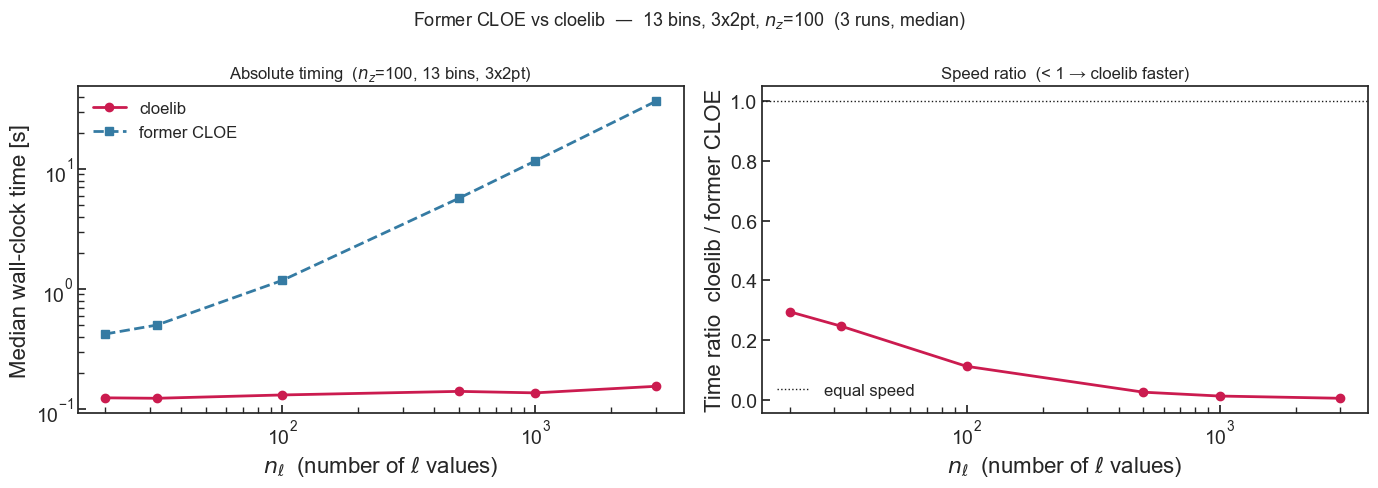

In [12]:
cloelib_time_arr = np.array([cloelib_comp_times[n] for n in former_cloe_nell])
ratio_arr        = cloelib_time_arr / former_cloe_time_s

col_cloelib = sns.color_palette("rocket", 3)[1]
col_cloe    = sns.color_palette("mako",   3)[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_t, ax_r = axes

ax_t.plot(former_cloe_nell, cloelib_time_arr, color=col_cloelib, lw=2,
          marker='o', label='cloelib')
ax_t.plot(former_cloe_nell, former_cloe_time_s, color=col_cloe, lw=2,
          marker='s', ls='--', label='former CLOE')

ax_t.set_xlabel(r'$n_\ell$  (number of $\ell$ values)')
ax_t.set_ylabel('Median wall-clock time [s]')
ax_t.set_title(f'Absolute timing  ($n_z$={NZ_CLOE_COMP}, 13 bins, 3x2pt)')
ax_t.set_xscale('log')
ax_t.set_yscale('log')
ax_t.legend(frameon=False)
ax_t.tick_params(axis='both', which='both', direction='in')

ax_r.plot(former_cloe_nell, ratio_arr, color=col_cloelib, lw=2, marker='o')
ax_r.axhline(1.0, color='k', lw=1, ls=':', label='equal speed')
ax_r.set_xlabel(r'$n_\ell$  (number of $\ell$ values)')
ax_r.set_ylabel('Time ratio  cloelib / former CLOE')
ax_r.set_title('Speed ratio  (< 1 → cloelib faster)')
ax_r.set_xscale('log')
ax_r.legend(frameon=False)
ax_r.tick_params(axis='both', which='both', direction='in')

plt.suptitle(f'Former CLOE vs cloelib  —  13 bins, 3x2pt, $n_z$={NZ_CLOE_COMP}  ({N_REPEAT_COMP} runs, median)',
             fontsize=13)
plt.tight_layout()
plt.savefig('time_comparison_cloe_vs_cloelib.png', dpi=150, bbox_inches='tight')
plt.show()


## Comparison on calling 3x2pt theory prediction through `cloelib` vs. `cloelike`

In [13]:
ells = np.logspace(np.log10(2), np.log10(2999), 32).astype(int)

In [14]:
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt

# Minimal `data`/`settings` pair -- only what get_theory_vector_full needs.
# No observed cells/covariance/mixing matrix required since we never call loglike().
data_like = {
    'z_arr': zs,
    'dndz_pos': my_dndz_norm,
    'dndz_she': my_dndz_norm,
    'ells': ells,
}
settings_like = {'scale_cuts': {}}

like_3x2pt = EuclidLikelihood_3x2pt(
    data=data_like,
    settings=settings_like,
    Background=CAMBBackground,
    LinPerturbations=HMemuLinearPerturbations,
    NonLinPerturbations=HMemuNonLinearPerturbations,
    mode='uncoupled',  # un-mixed get_Cl path, matching the direct cloelib calls above
)

# parameters dict = cosmology + astrophysical/nuisance parameters expected
# by get_theory_vector_full (same fiducial values used for `nuisance_pos`/`nuisance_she` above)
parameters = {
    'H0': 70.0, 'Omega_cdm0': 0.25, 'Omega_b0': 0.05, 'Omega_k0': 0.0,
    'w0': -1.0, 'wa': 0.0, 'ns': 0.96, 'As': 2e-9, 'mnu': 0.06,
    'gamma_MG': 0.545, 'N_mnu': 1, 'log10TAGN': 7.8,
    **nuisance_pos, **nuisance_she,
}

print("cloelike EuclidLikelihood_3x2pt setup done")

cloelike EuclidLikelihood_3x2pt setup done


In [15]:
# ── Correctness check ──────────────────────────────────────────────────────
# theory_prediction stores the raw {(species, species, i, j): AngularPowerSpectrum}
# dict built internally by get_theory_vector_full -- compare it directly against
# the cells returned by the plain cloelib call `compute_cls_cloelib()`.
_ = like_3x2pt.get_theory_vector_full(parameters)
cells_direct = compute_cls_cloelib()
cells_wrapped = like_3x2pt.theory_prediction

common_keys = set(cells_direct) & set(cells_wrapped)
print(f"Compared {len(common_keys)} / {len(cells_direct)} spectra")

max_abs_diff = max(
    np.max(np.abs(np.asarray(cells_direct[k]) - np.asarray(cells_wrapped[k])))
    for k in common_keys
)
max_rel_diff = max(
    np.max(np.abs(np.asarray(cells_direct[k]) - np.asarray(cells_wrapped[k]))
           / np.clip(np.abs(np.asarray(cells_direct[k])), 1e-300, None))
    for k in common_keys
)
all_close = all(
    np.allclose(np.asarray(cells_direct[k]), np.asarray(cells_wrapped[k]))
    for k in common_keys
)

print(f"All spectra match (np.allclose): {all_close}")
print(f"Max absolute difference: {max_abs_diff:.3e}")
print(f"Max relative difference: {max_rel_diff:.3e}")

Compared 351 / 351 spectra
All spectra match (np.allclose): True
Max absolute difference: 0.000e+00
Max relative difference: 0.000e+00


In [16]:
# ── Timing comparison ───────────────────────────────────────────────────────
# get_theory_vector_full rebuilds Background/LinPerturbations/NonLinPerturbations
# (and the tracers) from scratch on every call -- required since `parameters` can
# change between calls in a sampler -- so a naive comparison against
# compute_cls_cloelib() (which reuses already-built tracers) isn't apples-to-apples.
# We therefore also time an equivalent direct pipeline that rebuilds everything too.
N_REPEAT_WRAP = 10

def compute_cls_cloelib_full_pipeline():
    """Rebuild background/perturbations/tracers from scratch each call, matching
    what get_theory_vector_full does internally -- for a fair timing comparison."""
    bg = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
                         w0=-1.0, wa=0.0, Omega_k0=0.0, ns=0.96, As=2e-9,
                         mnu=0.06, gamma_MG=0.545, N_mnu=1)
    lin = HMemuLinearPerturbations(bg, zs)
    nlin = HMemuNonLinearPerturbations(bg, lin, zs, log10TAGN=7.8)
    tr_pos = PositionsTracer(perturbations=nlin, dndz=my_dndz_norm, z=zs,
                              galaxy_bias_model='poly', nuisance_params=nuisance_pos)
    tr_she = ShearTracer(perturbations=nlin, dndz=my_dndz_norm, z=zs,
                          nuisance_params=nuisance_she)
    c = {}
    c.update(AngularTwoPoint(tr_pos, tr_pos).get_Cl(ells, 0, nlin.k))
    c.update(AngularTwoPoint(tr_pos, tr_she).get_Cl(ells, 0, nlin.k))
    c.update(AngularTwoPoint(tr_she, tr_she).get_Cl(ells, 0, nlin.k))
    return c

t_direct = timeit.repeat(compute_cls_cloelib, repeat=N_REPEAT_WRAP, number=1)
t_direct_full = timeit.repeat(compute_cls_cloelib_full_pipeline, repeat=N_REPEAT_WRAP, number=1)
t_wrapped = timeit.repeat(lambda: like_3x2pt.get_theory_vector_full(parameters),
                           repeat=N_REPEAT_WRAP, number=1)

med_direct = np.median(t_direct)
med_direct_full = np.median(t_direct_full)
med_wrapped = np.median(t_wrapped)

print(f"cloelib direct (tracers reused):      {med_direct:.3f}s")
print(f"cloelib direct (full pipeline):       {med_direct_full:.3f}s")
print(f"cloelike get_theory_vector_full:      {med_wrapped:.3f}s")
print()
print(f"Ratio wrapped / direct (naive, reused tracers): {med_wrapped / med_direct:.2f}x")
print(f"Ratio wrapped / direct (fair, full pipeline):   {med_wrapped / med_direct_full:.2f}x")

cloelib direct (tracers reused):      0.119s
cloelib direct (full pipeline):       0.209s
cloelike get_theory_vector_full:      0.128s

Ratio wrapped / direct (naive, reused tracers): 1.07x
Ratio wrapped / direct (fair, full pipeline):   0.61x


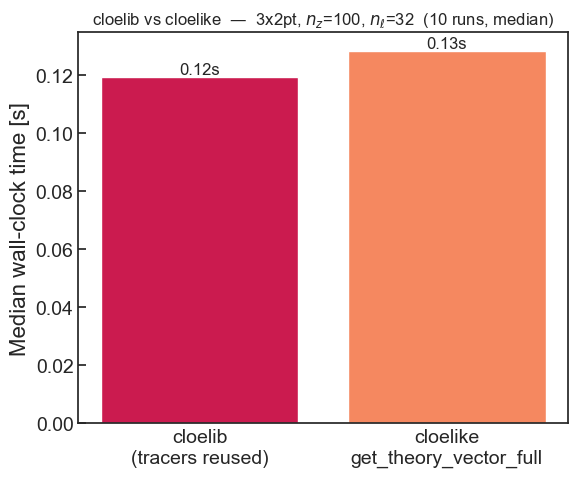

In [17]:
labels = ['cloelib\n(tracers reused)', 'cloelike\nget_theory_vector_full']
times = [med_direct, med_wrapped]
colors_bar = [sns.color_palette("rocket", 3)[1], sns.color_palette("rocket", 3)[2], sns.color_palette("mako", 3)[1]]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, times, color=colors_bar)
plt.ylabel('Median wall-clock time [s]')
plt.title(f'cloelib vs cloelike  —  3x2pt, $n_z$={len(zs)}, $n_\\ell$={len(ells)}  ({N_REPEAT_WRAP} runs, median)')
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{t:.2f}s',
              ha='center', va='bottom', fontsize=12)
plt.tick_params(axis='both', which='both', direction='in')
plt.tight_layout()
plt.savefig('time_comparison_cloelib_vs_cloelike.png', dpi=150, bbox_inches='tight')
plt.show()

### Same comparison, using CAMB as the linear/nonlinear perturbation engine

Same setup as above, but swapping `HMemuLinearPerturbations`/`HMemuNonLinearPerturbations` for
`CAMBLinearPerturbations`/`CAMBNonLinearPerturbations` (reusing the same `background` object
built earlier). CAMB is far more expensive to build than the HMcode2020 emulator (~5s vs
~0.1s), which makes the redundant cosmology rebuilds that `get_theory_vector_full` used to do
(one per WL/GCph/GGL mixin) far more costly -- so this is exactly the case the caching fix in
`cloelike` was meant to help.

Note: `EuclidLikelihood_photo_Cls.py` calls `NonLinPerturbations(..., log10TAGN=...)` without a
`nonlinear_model` argument, and `CAMBNonLinearPerturbations` only applies `log10TAGN` when a
`nonlinear_model` (e.g. `'mead2020_feedback'`) is also supplied -- so `log10TAGN` is a no-op
here for both the direct call and the wrapper (CAMB falls back to its default halofit model).
We keep the same call signature on both sides below so the comparison stays apples-to-apples.

In [18]:
from cloelib.cosmology.camb_cosmology import CAMBLinearPerturbations, CAMBNonLinearPerturbations

# Fresh Background (CAMBLinearPerturbations/CAMBNonLinearPerturbations mutate CAMB's internal
# parameter object in place -- e.g. WantCls/set_matter_power -- so we don't reuse `background`
# from the HMcode2020Emu section above and instead build a dedicated one for this section).
background_camb = CAMBBackground(
    H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
    w0=-1.0, wa=0.0, Omega_k0=0.0,
    ns=0.96, As=2e-9, mnu=0.06,
    gamma_MG=0.545, N_mnu=1,
)
linear_pert_camb = CAMBLinearPerturbations(background_camb, zs)
nonlin_pert_camb = CAMBNonLinearPerturbations(background_camb, linear_pert_camb, zs, log10TAGN=7.8)

tracer_pos_camb = PositionsTracer(
    perturbations=nonlin_pert_camb, dndz=my_dndz_norm,
    z=zs, galaxy_bias_model='poly', nuisance_params=nuisance_pos,
)
tracer_she_camb = ShearTracer(
    perturbations=nonlin_pert_camb, dndz=my_dndz_norm,
    z=zs, nuisance_params=nuisance_she,
)

tp_gg_camb = AngularTwoPoint(tracer_pos_camb, tracer_pos_camb)
tp_ge_camb = AngularTwoPoint(tracer_pos_camb, tracer_she_camb)
tp_ee_camb = AngularTwoPoint(tracer_she_camb, tracer_she_camb)

def compute_cls_cloelib_camb():
    cells = {}
    cells.update(tp_gg_camb.get_Cl(ells, 0, nonlin_pert_camb.k))
    cells.update(tp_ge_camb.get_Cl(ells, 0, nonlin_pert_camb.k))
    cells.update(tp_ee_camb.get_Cl(ells, 0, nonlin_pert_camb.k))
    return cells

# Reuse the same `data_like`/`settings_like`/`parameters` dicts from the HMcode2020Emu comparison above
like_3x2pt_camb = EuclidLikelihood_3x2pt(
    data=data_like,
    settings=settings_like,
    Background=CAMBBackground,
    LinPerturbations=CAMBLinearPerturbations,
    NonLinPerturbations=CAMBNonLinearPerturbations,
    mode='uncoupled',
)

print("cloelike EuclidLikelihood_3x2pt (CAMB) setup done")

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
cloelike EuclidLikelihood_3x2pt (CAMB) setup done


In [19]:
# ── Correctness check (CAMB) ────────────────────────────────────────────────
_ = like_3x2pt_camb.get_theory_vector_full(parameters)
cells_direct_camb = compute_cls_cloelib_camb()
cells_wrapped_camb = like_3x2pt_camb.theory_prediction

common_keys_camb = set(cells_direct_camb) & set(cells_wrapped_camb)
print(f"Compared {len(common_keys_camb)} / {len(cells_direct_camb)} spectra")

max_abs_diff_camb = max(
    np.max(np.abs(np.asarray(cells_direct_camb[k]) - np.asarray(cells_wrapped_camb[k])))
    for k in common_keys_camb
)
max_rel_diff_camb = max(
    np.max(np.abs(np.asarray(cells_direct_camb[k]) - np.asarray(cells_wrapped_camb[k]))
           / np.clip(np.abs(np.asarray(cells_direct_camb[k])), 1e-300, None))
    for k in common_keys_camb
)
all_close_camb = all(
    np.allclose(np.asarray(cells_direct_camb[k]), np.asarray(cells_wrapped_camb[k]))
    for k in common_keys_camb
)

print(f"All spectra match (np.allclose): {all_close_camb}")
print(f"Max absolute difference: {max_abs_diff_camb:.3e}")
print(f"Max relative difference: {max_rel_diff_camb:.3e}")

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Compared 351 / 351 spectra
All spectra match (np.allclose): True
Max absolute difference: 0.000e+00
Max relative difference: 0.000e+00


In [20]:
# ── Timing comparison (CAMB) ────────────────────────────────────────────────
# CAMB's Background+LinPerturbations+NonLinPerturbations build is ~5s (vs ~0.1s for the
# HMcode2020 emulator), so we use fewer repeats here to keep runtime reasonable.
N_REPEAT_CAMB = 3

def compute_cls_cloelib_camb_full_pipeline():
    """Rebuild background/perturbations/tracers from scratch each call, matching
    what get_theory_vector_full does internally -- for a fair timing comparison."""
    bg = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
                         w0=-1.0, wa=0.0, Omega_k0=0.0, ns=0.96, As=2e-9,
                         mnu=0.06, gamma_MG=0.545, N_mnu=1)
    lin = CAMBLinearPerturbations(bg, zs)
    nlin = CAMBNonLinearPerturbations(bg, lin, zs, log10TAGN=7.8)
    tr_pos = PositionsTracer(perturbations=nlin, dndz=my_dndz_norm, z=zs,
                              galaxy_bias_model='poly', nuisance_params=nuisance_pos)
    tr_she = ShearTracer(perturbations=nlin, dndz=my_dndz_norm, z=zs,
                          nuisance_params=nuisance_she)
    c = {}
    c.update(AngularTwoPoint(tr_pos, tr_pos).get_Cl(ells, 0, nlin.k))
    c.update(AngularTwoPoint(tr_pos, tr_she).get_Cl(ells, 0, nlin.k))
    c.update(AngularTwoPoint(tr_she, tr_she).get_Cl(ells, 0, nlin.k))
    return c

t_direct_camb = timeit.repeat(compute_cls_cloelib_camb, repeat=N_REPEAT_CAMB, number=1)
t_direct_full_camb = timeit.repeat(compute_cls_cloelib_camb_full_pipeline, repeat=N_REPEAT_CAMB, number=1)
t_wrapped_camb = timeit.repeat(lambda: like_3x2pt_camb.get_theory_vector_full(parameters),
                                repeat=N_REPEAT_CAMB, number=1)

med_direct_camb = np.median(t_direct_camb)
med_direct_full_camb = np.median(t_direct_full_camb)
med_wrapped_camb = np.median(t_wrapped_camb)

print(f"cloelib direct (tracers reused):      {med_direct_camb:.3f}s")
print(f"cloelib direct (full pipeline):       {med_direct_full_camb:.3f}s")
print(f"cloelike get_theory_vector_full:      {med_wrapped_camb:.3f}s")
print()
print(f"Ratio wrapped / direct (naive, reused tracers): {med_wrapped_camb / med_direct_camb:.2f}x")
print(f"Ratio wrapped / direct (fair, full pipeline):   {med_wrapped_camb / med_direct_full_camb:.2f}x")

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
cloelib direct (tracers reused):      0.142s
cloelib direct (full pipeline):       5.023s
cloelike get_theory_vector_full:      0.131s

Ratio wrapped / direct (naive, reused tracers): 0.92x
Ratio wrapped / direct (fair, full pipeline):   0.03x


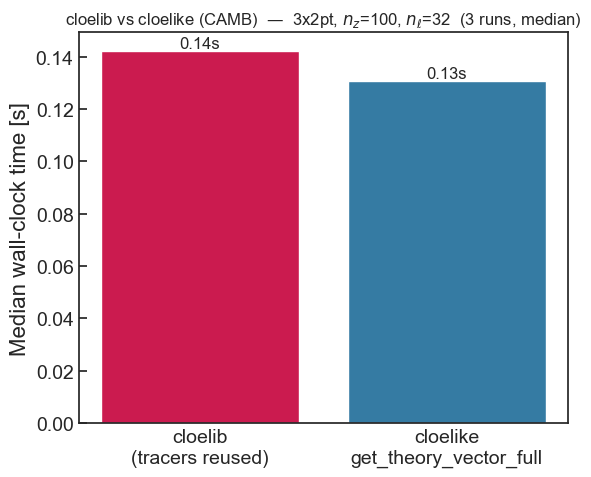

In [21]:
labels_camb = ['cloelib\n(tracers reused)', 'cloelike\nget_theory_vector_full']
times_camb = [med_direct_camb, med_wrapped_camb]
colors_bar_camb = [sns.color_palette("rocket", 3)[1], sns.color_palette("mako", 3)[1]]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels_camb, times_camb, color=colors_bar_camb)
plt.ylabel('Median wall-clock time [s]')
plt.title(f'cloelib vs cloelike (CAMB)  —  3x2pt, $n_z$={len(zs)}, $n_\\ell$={len(ells)}  ({N_REPEAT_CAMB} runs, median)')
for bar, t in zip(bars, times_camb):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{t:.2f}s',
              ha='center', va='bottom', fontsize=12)
plt.tick_params(axis='both', which='both', direction='in')
plt.tight_layout()
plt.savefig('time_comparison_cloelib_vs_cloelike_camb.png', dpi=150, bbox_inches='tight')
plt.show()

### Sweep over $n_z$ / $n_\ell$, for both perturbation engines

Same `cloelib` vs `cloelike` comparison as above, but now swept over a small grid of
`(n_z, n_ell)` and repeated for **both** perturbation engines (HMcode2020Emu and CAMB), each
point averaged (mean) over `N_REPEAT_SWEEP = 10` runs.

For a fair, "cold-start" comparison at every grid point, both sides rebuild everything from
scratch on every one of the 10 repeats:
- **`cloelib` (full pipeline)**: rebuild `Background`/`LinPerturbations`/`NonLinPerturbations`
  + tracers, then compute GG/GE/EE (same pattern as the single-point "full pipeline" cells above).
- **`cloelike` (cold)**: construct a *fresh* `EuclidLikelihood_3x2pt` instance and immediately
  call `get_theory_vector_full` on it, so its internal cache starts empty every repeat (calling
  it repeatedly on the *same* instance would hit the cache after the first call and just measure
  Python overhead, not the real per-call cost of a sampler visiting a new point in cosmology).

CAMB's build cost is ~5s per point regardless of `n_z`/`n_ell` (see the section above), so this
grid is deliberately small to keep total runtime reasonable.

In [30]:
N_REPEAT_SWEEP = 10  # averaged (mean) over this many repeats per (engine, n_z, n_ell) point

nz_values_sweep   = [100, 200, 250]
nell_values_sweep = [10, 20 , 50, 100, 200, 500, 1000]

engines = {
    'HMcode2020Emu': (HMemuLinearPerturbations, HMemuNonLinearPerturbations),
    'CAMB':          (CAMBLinearPerturbations, CAMBNonLinearPerturbations),
}

def _make_direct_full_pipeline(LinPerturbations, NonLinPerturbations, zs_cfg, dndz_cfg, ells_cfg):
    """Cold: rebuild Background/LinPerturbations/NonLinPerturbations + tracers every call."""
    def _run():
        bg = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05, w0=-1.0, wa=0.0, Omega_k0=0.0,
                             ns=0.96, As=2e-9, mnu=0.06, gamma_MG=0.545, N_mnu=1)
        lin = LinPerturbations(bg, zs_cfg)
        nlin = NonLinPerturbations(bg, lin, zs_cfg, log10TAGN=7.8)
        tr_pos = PositionsTracer(perturbations=nlin, dndz=dndz_cfg, z=zs_cfg,
                                  galaxy_bias_model='poly', nuisance_params=nuisance_pos)
        tr_she = ShearTracer(perturbations=nlin, dndz=dndz_cfg, z=zs_cfg,
                              nuisance_params=nuisance_she)
        c = {}
        c.update(AngularTwoPoint(tr_pos, tr_pos).get_Cl(ells_cfg, 0, nlin.k))
        c.update(AngularTwoPoint(tr_pos, tr_she).get_Cl(ells_cfg, 0, nlin.k))
        c.update(AngularTwoPoint(tr_she, tr_she).get_Cl(ells_cfg, 0, nlin.k))
        return c
    return _run

def _make_direct_reused_cls(tr_pos, tr_she, nlin, ells_cfg):
    """Warm: perturbations/tracers already built -- times only the Cl computation itself."""
    def _run():
        c = {}
        c.update(AngularTwoPoint(tr_pos, tr_pos).get_Cl(ells_cfg, 0, nlin.k))
        c.update(AngularTwoPoint(tr_pos, tr_she).get_Cl(ells_cfg, 0, nlin.k))
        c.update(AngularTwoPoint(tr_she, tr_she).get_Cl(ells_cfg, 0, nlin.k))
        return c
    return _run

def _make_wrapped_cold(LinPerturbations, NonLinPerturbations, data_cfg):
    """Cold: fresh EuclidLikelihood_3x2pt instance every call, so its perturbations/tracer
    caches start empty every time (real cost of a sampler visiting a brand-new point)."""
    def _run():
        like = EuclidLikelihood_3x2pt(
            data=data_cfg, settings=settings_like,
            Background=CAMBBackground, LinPerturbations=LinPerturbations,
            NonLinPerturbations=NonLinPerturbations, mode='uncoupled',
        )
        return like.get_theory_vector_full(parameters)
    return _run

def _make_wrapped_warm(like_warm):
    """Warm: same instance every call (already warmed up once beforehand), so its internal
    perturbations/tracer caches all hit -- isolates the Cl computation cost through the wrapper,
    without constructing a fresh instance or recomputing the perturbations each time."""
    def _run():
        return like_warm.get_theory_vector_full(parameters)
    return _run

results_sweep = {}  # results_sweep[engine][(nz, nell)] = {'direct_full', 'direct_reused', 'wrapped_cold', 'wrapped_warm'} (mean seconds)

for engine_name, (LinP, NonLinP) in engines.items():
    print(f"\n=== {engine_name} ===")
    results_sweep[engine_name] = {}
    for nz in nz_values_sweep:
        zs_cfg = np.linspace(1e-4, 3.0, nz)
        dndz_cfg = resample_dndz(dndz_norm, z_nz, zs_cfg)
        for nell in nell_values_sweep:
            ells_cfg = np.unique(np.geomspace(2, 2999, nell).astype(int))
            data_cfg = {'z_arr': zs_cfg, 'dndz_pos': dndz_cfg, 'dndz_she': dndz_cfg, 'ells': ells_cfg}

            # Build once (untimed) -- shared by both the "reused tracers" and "warm wrapper" timings
            bg_warm = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05, w0=-1.0, wa=0.0, Omega_k0=0.0,
                                      ns=0.96, As=2e-9, mnu=0.06, gamma_MG=0.545, N_mnu=1)
            lin_warm = LinP(bg_warm, zs_cfg)
            nlin_warm = NonLinP(bg_warm, lin_warm, zs_cfg, log10TAGN=7.8)
            tr_pos_warm = PositionsTracer(perturbations=nlin_warm, dndz=dndz_cfg, z=zs_cfg,
                                           galaxy_bias_model='poly', nuisance_params=nuisance_pos)
            tr_she_warm = ShearTracer(perturbations=nlin_warm, dndz=dndz_cfg, z=zs_cfg,
                                       nuisance_params=nuisance_she)

            like_warm = EuclidLikelihood_3x2pt(
                data=data_cfg, settings=settings_like,
                Background=CAMBBackground, LinPerturbations=LinP,
                NonLinPerturbations=NonLinP, mode='uncoupled',
            )
            _ = like_warm.get_theory_vector_full(parameters)  # warm its cache once, untimed

            t_direct_full = timeit.repeat(
                _make_direct_full_pipeline(LinP, NonLinP, zs_cfg, dndz_cfg, ells_cfg),
                repeat=N_REPEAT_SWEEP, number=1,
            )
            t_direct_reused = timeit.repeat(
                _make_direct_reused_cls(tr_pos_warm, tr_she_warm, nlin_warm, ells_cfg),
                repeat=N_REPEAT_SWEEP, number=1,
            )
            t_wrapped_cold = timeit.repeat(
                _make_wrapped_cold(LinP, NonLinP, data_cfg),
                repeat=N_REPEAT_SWEEP, number=1,
            )
            t_wrapped_warm = timeit.repeat(
                _make_wrapped_warm(like_warm),
                repeat=N_REPEAT_SWEEP, number=1,
            )

            means = {
                'direct_full': np.mean(t_direct_full),
                'direct_reused': np.mean(t_direct_reused),
                'wrapped_cold': np.mean(t_wrapped_cold),
                'wrapped_warm': np.mean(t_wrapped_warm),
            }
            results_sweep[engine_name][(nz, nell)] = means

            print(f"  n_z={nz:4d}  n_ell={nell:4d} | "
                  f"direct full {means['direct_full']:6.3f}s  reused {means['direct_reused']:6.3f}s  |  "
                  f"wrapped cold {means['wrapped_cold']:6.3f}s  warm {means['wrapped_warm']:6.3f}s")

print("\nSweep complete.")


=== HMcode2020Emu ===
  n_z= 100  n_ell=  10 | direct full  0.213s  reused  0.122s  |  wrapped cold  0.213s  warm  0.122s
  n_z= 100  n_ell=  20 | direct full  0.206s  reused  0.122s  |  wrapped cold  0.212s  warm  0.124s
  n_z= 100  n_ell=  50 | direct full  0.206s  reused  0.120s  |  wrapped cold  0.212s  warm  0.121s
  n_z= 100  n_ell= 100 | direct full  0.204s  reused  0.121s  |  wrapped cold  0.217s  warm  0.126s
  n_z= 100  n_ell= 200 | direct full  0.207s  reused  0.123s  |  wrapped cold  0.218s  warm  0.126s
  n_z= 100  n_ell= 500 | direct full  0.210s  reused  0.129s  |  wrapped cold  0.220s  warm  0.131s
  n_z= 100  n_ell=1000 | direct full  0.217s  reused  0.135s  |  wrapped cold  0.224s  warm  0.136s
  n_z= 200  n_ell=  10 | direct full  0.264s  reused  0.120s  |  wrapped cold  0.257s  warm  0.121s
  n_z= 200  n_ell=  20 | direct full  0.244s  reused  0.120s  |  wrapped cold  0.257s  warm  0.121s
  n_z= 200  n_ell=  50 | direct full  0.253s  reused  0.129s  |  wrapped cold

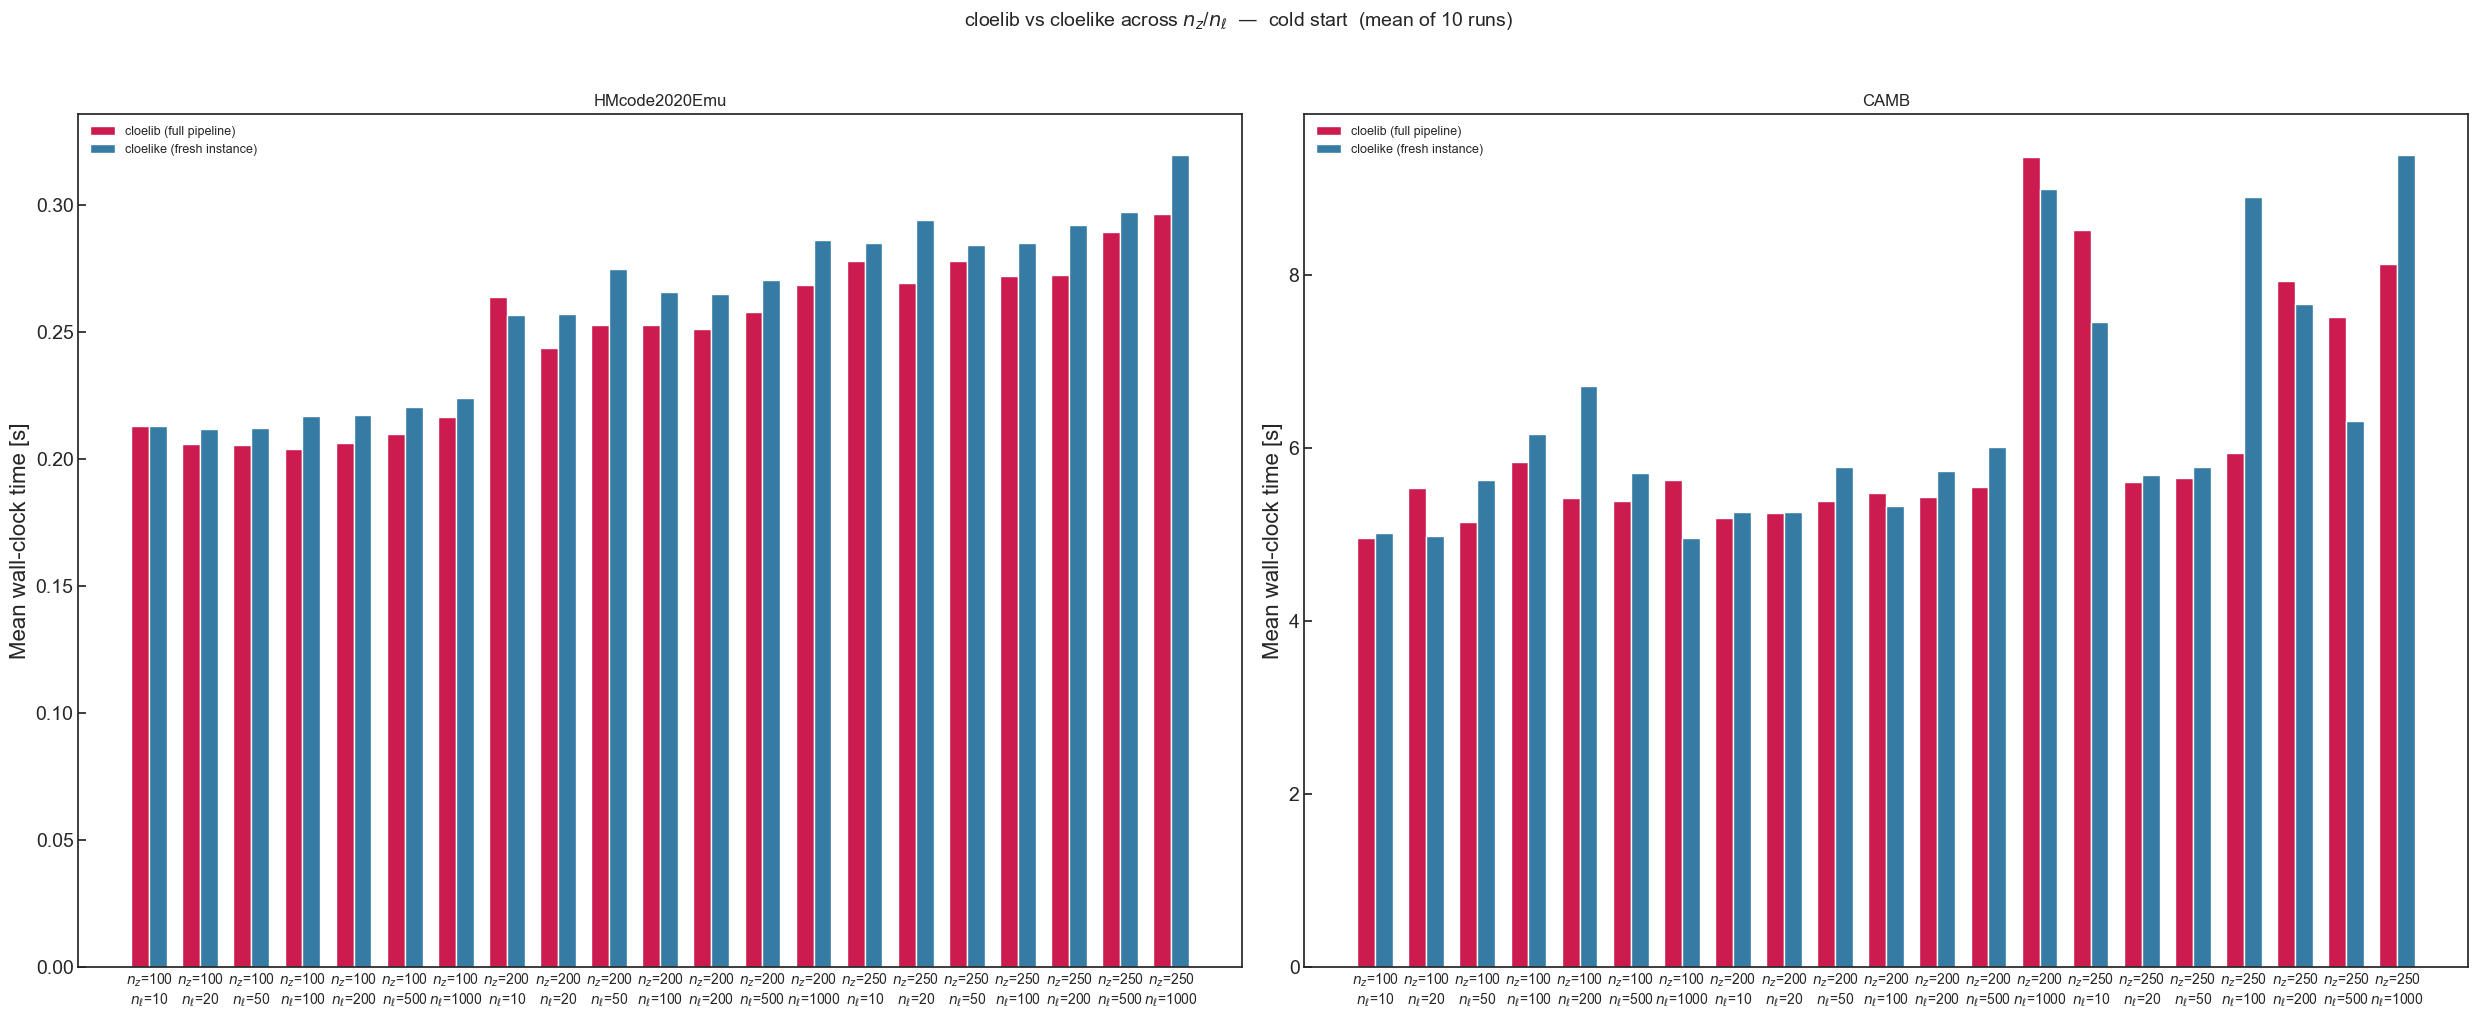

In [38]:
configs = [(nz, nell) for nz in nz_values_sweep for nell in nell_values_sweep]
config_labels = [f'$n_z$={nz}\n$n_\\ell$={nell}' for nz, nell in configs]
x = np.arange(len(configs))
width = 0.35

# Cold-start comparison: full rebuild each call (both sides) -- the realistic per-call cost
# when a sampler visits a brand-new point in cosmology.
fig, axes = plt.subplots(1, 2, figsize=(25, 10))
for ax, engine_name in zip(axes, engines):
    direct_vals = [results_sweep[engine_name][cfg]['direct_full'] for cfg in configs]
    wrapped_vals = [results_sweep[engine_name][cfg]['wrapped_cold'] for cfg in configs]

    ax.bar(x - width / 2, direct_vals, width, label='cloelib (full pipeline)',
           color=sns.color_palette("rocket", 3)[1])
    ax.bar(x + width / 2, wrapped_vals, width, label='cloelike (fresh instance)',
           color=sns.color_palette("mako", 3)[1])
    ax.set_xticks(x)
    ax.set_xticklabels(config_labels, fontsize=10)
    ax.set_ylabel('Mean wall-clock time [s]')
    ax.set_title(engine_name)
    ax.legend(frameon=False, fontsize=9)
    ax.tick_params(axis='both', which='both', direction='in')

plt.suptitle(f'cloelib vs cloelike across $n_z$/$n_\\ell$  —  cold start  (mean of {N_REPEAT_SWEEP} runs)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('time_comparison_cloelib_vs_cloelike_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

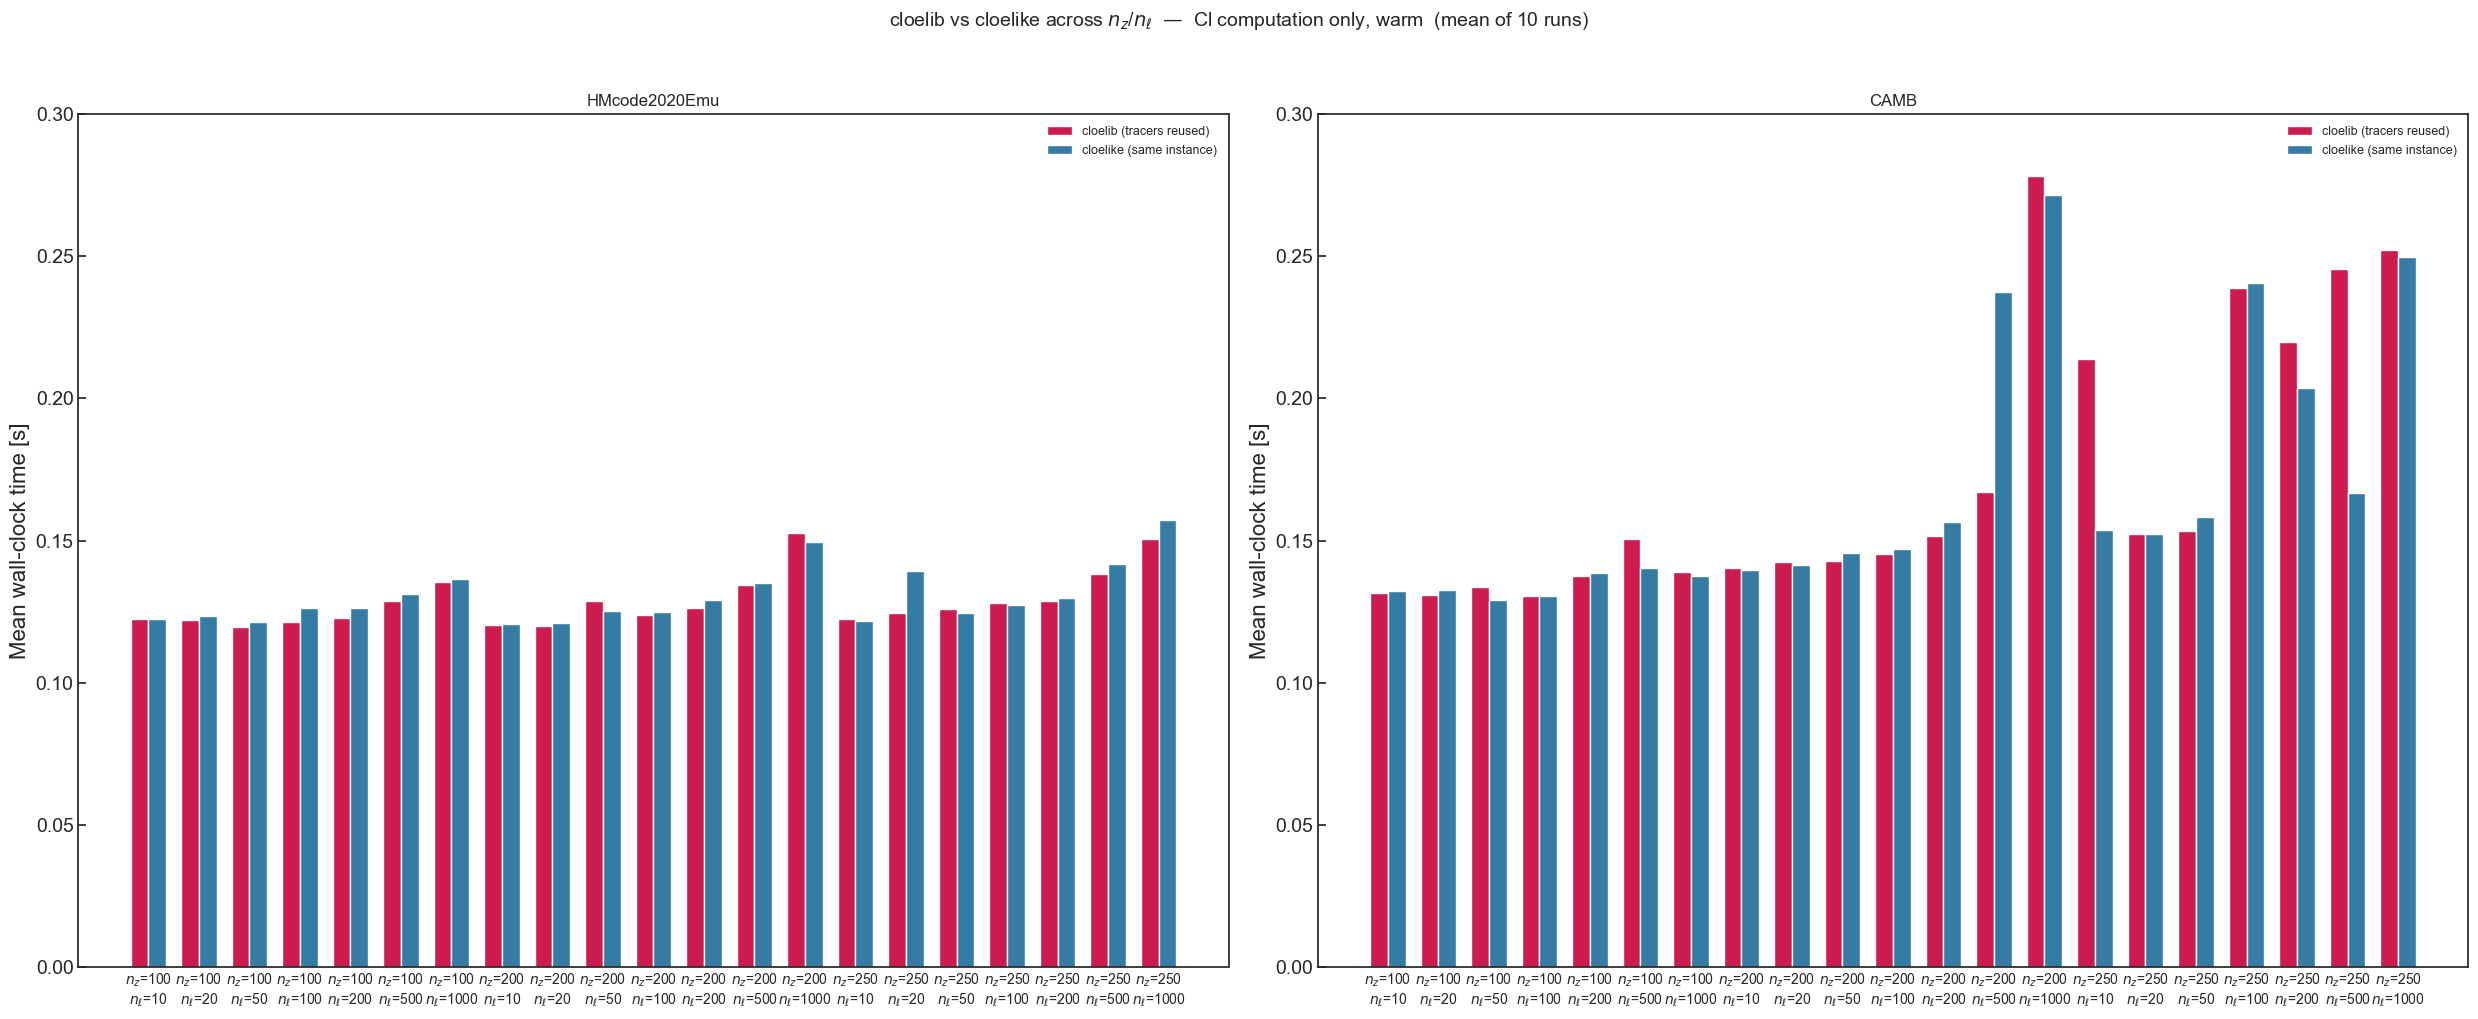

In [40]:
# Warm comparison: perturbations/tracers (and, for cloelike, the whole instance) are already
# built and cached -- this isolates the Cl computation itself, without construction overhead.
fig, axes = plt.subplots(1, 2, figsize=(25, 10))
for ax, engine_name in zip(axes, engines):
    direct_vals = [results_sweep[engine_name][cfg]['direct_reused'] for cfg in configs]
    wrapped_vals = [results_sweep[engine_name][cfg]['wrapped_warm'] for cfg in configs]

    ax.bar(x - width / 2, direct_vals, width, label='cloelib (tracers reused)',
           color=sns.color_palette("rocket", 3)[1])
    ax.bar(x + width / 2, wrapped_vals, width, label='cloelike (same instance)',
           color=sns.color_palette("mako", 3)[1])
    ax.set_xticks(x)
    ax.set_xticklabels(config_labels, fontsize=10)
    ax.set_ylabel('Mean wall-clock time [s]')
    ax.set_title(engine_name)
    ax.legend(frameon=False, fontsize=9)
    ax.tick_params(axis='both', which='both', direction='in')
    ax.set_ylim(0, 0.3)  # avoid negative y-axis due to small noise in mean timings

plt.suptitle(f'cloelib vs cloelike across $n_z$/$n_\\ell$  —  Cl computation only, warm  (mean of {N_REPEAT_SWEEP} runs)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('time_comparison_cloelib_vs_cloelike_sweep_warm.png', dpi=150, bbox_inches='tight')
plt.show()